# Comparision of different PRNGs (Model 1)

The Python code in this notebook will load the simulation results stored in the `statistics` folder and will generate the histograms for model 1 shown in the report.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import libs.stattools as stattools

plt.style.use('seaborn-v0_8')

## Load and process data

In [7]:
# Actual mean and standard deviation of the log-normal distribution used in the model
mean = 200
std = 50

# Stored histogram values
input_file = "statistics/results1Log-Histogram.txt"

In [8]:
df = pd.read_csv(input_file, header=None, names=["rng_mode", "i", "x",], sep="\t")

dist = stattools.generate_log_normal_histogram(mean, std, 3600)

In [9]:
values1=list(df[df["rng_mode"] == "ThreadLocalRandom"]["x"])
n=np.sum(values1)
density1 = values1 / n

values2=list(df[df["rng_mode"] == "Drand48"]["x"])
n=np.sum(values2)
density2 = values2 / n

## Plot comparison histograms

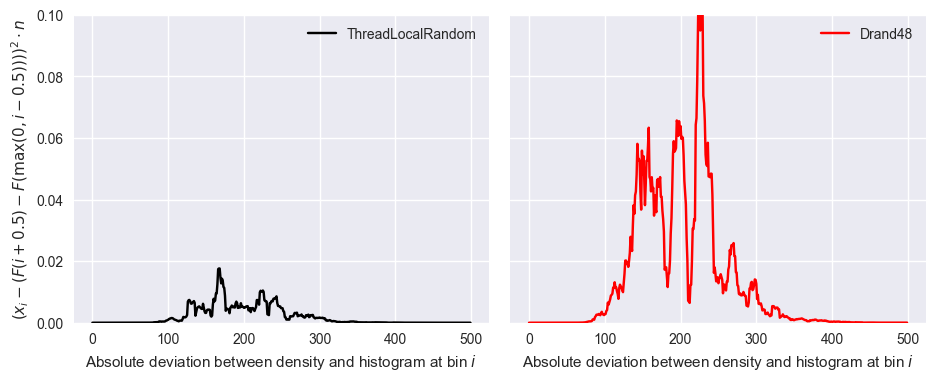

In [ ]:
y1 = (density1 - dist)**2 * n
y2 = (density2 - dist)**2 * n

# Moving average to smooth the curves
y1 = np.convolve(y1, np.ones(10) / 10, mode='valid')
y2 = np.convolve(y2, np.ones(10) / 10, mode='valid')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), sharey='row')
fig.subplots_adjust(wspace=0.05)

ax1.plot(y1[0:500], label="ThreadLocalRandom", color="black")
ax1.legend()
ax1.set_ylabel("$(x_i-(F(i+0.5)-F(\\max(0,i-0.5))))^2\\cdot n$")

ax2.plot(y2[0:500], label="Drand48", color="red")
ax2.legend()

ax1.set_xlabel("Absolute deviation between density and histogram at bin $i$")
ax2.set_xlabel("Absolute deviation between density and histogram at bin $i$")

ax1.set_ylim([0, 0.1])

# fig.savefig("plot1histogram.pdf", format="pdf", bbox_inches='tight', pad_inches=0)